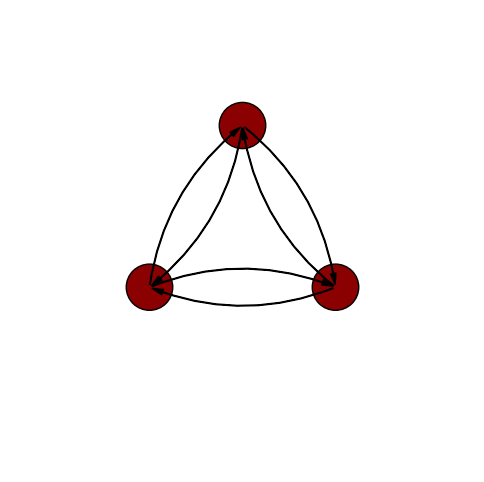

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

fig, ax = plt.subplots(figsize=(6,6))

ax.axis("off")
c_1 = patches.Circle(xy=[0.5, 0.75], radius=0.05, edgecolor="k", facecolor="darkred")
c_2 = patches.Circle(xy=[0.3, 0.4], radius=0.05, edgecolor="k", facecolor="darkred")
c_3 = patches.Circle(xy=[0.7, 0.4], radius=0.05, edgecolor="k", facecolor="darkred")

style = "Simple, tail_width=0.5, head_width=4, head_length=8"
kw = dict(arrowstyle=style, color="k")

a_12 = patches.FancyArrowPatch((0.3, 0.4), (0.5, 0.75), connectionstyle="arc3, rad=-.2", **kw)
a_21 = patches.FancyArrowPatch((0.5, 0.75), (0.3, 0.4), connectionstyle="arc3, rad=-.2", **kw)
a_23 = patches.FancyArrowPatch((0.5, 0.75), (0.7, 0.4), connectionstyle="arc3, rad=-.2", **kw)
a_32 = patches.FancyArrowPatch((0.7, 0.4), (0.5, 0.75), connectionstyle="arc3, rad=-.2", **kw)
a_31 = patches.FancyArrowPatch((0.7, 0.4), (0.3, 0.4), connectionstyle="arc3, rad=-.2", **kw)
a_13 = patches.FancyArrowPatch((0.3, 0.4), (0.7, 0.4), connectionstyle="arc3, rad=-.2", **kw)

ax.add_artist(c_1)
ax.add_artist(c_2)
ax.add_artist(c_3)

ax.add_artist(a_12)
ax.add_artist(a_21)
ax.add_artist(a_23)
ax.add_artist(a_32)
ax.add_artist(a_31)
ax.add_artist(a_13)

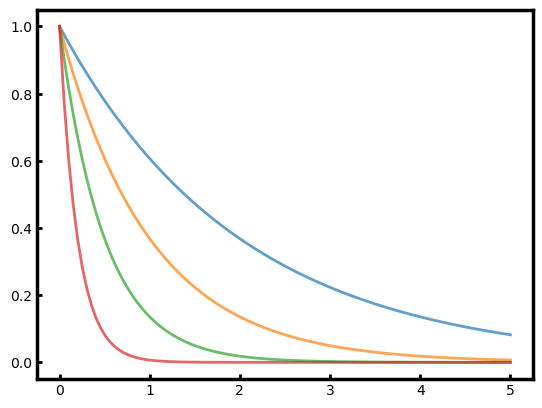

In [14]:
lambdas = [0.5, 1.0, 2.0, 5.0]
fig, ax = plt.subplots()
ax.tick_params(which="major", direction="in", width=2)
ax.spines[:].set_linewidth(2.5)
x = np.linspace(0, 5, 100)
for l in lambdas:
    ax.plot(x, np.exp(-l*x), alpha=.7, lw=2)

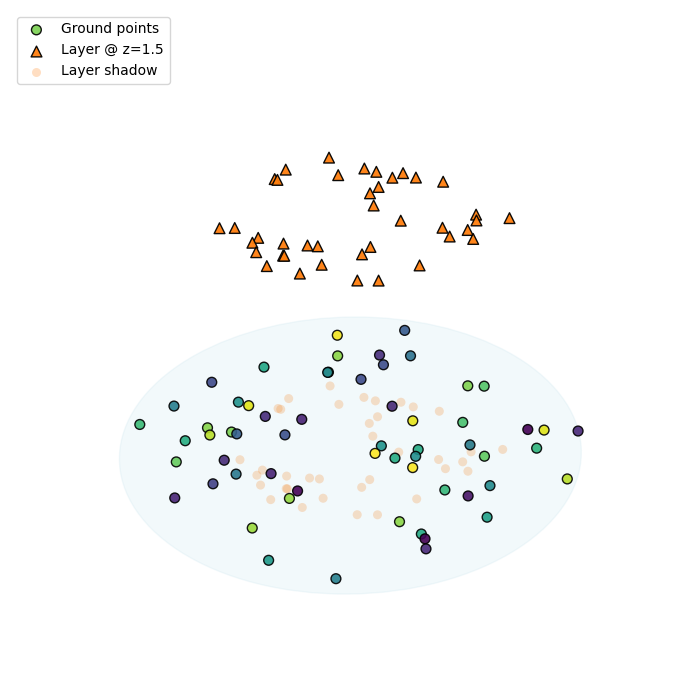

In [19]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from mpl_toolkits.mplot3d import art3d
import numpy as np

def scatter_ground_and_layer(
    x1, y1, x2, y2,
    h=1.0,
    c1=None, c2=None,
    s1=50, s2=60,
    show_shadows=False,
    show_ground_plane=False,
    ground_circle_center=(0.5, 0.5),
    ground_circle_radius=0.6,
    ground_circle_color="lightblue",
    ground_circle_alpha=0.15
):
    """
    Plot two scatters in 3D: one on the ground (z=0) and one at height h.
    Adds an optional circle on the ground plane.
    """
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Z coordinates
    z1 = np.zeros_like(x1)
    z2 = np.full_like(x2, h, dtype=float)

    # Main scatters
    ax.scatter(x1, y1, z1, c=c1, s=s1, alpha=0.9, edgecolors="k", label="Ground points")
    ax.scatter(x2, y2, z2, c=c2, s=s2, alpha=0.95, edgecolors="k", marker="^", label=f"Layer @ z={h}")

    # Optional: shadows of elevated points on ground
    if show_shadows:
        ax.scatter(
            x2, y2, np.zeros_like(z2),
            c=c2 if isinstance(c2, str) else "k",
            s=s2*0.7, alpha=0.25, marker="o", linewidths=0, label="Layer shadow"
        )

    # Add ground circle at z=0
    ground_circle = Circle(
        ground_circle_center,
        ground_circle_radius,
        color=ground_circle_color,
        alpha=ground_circle_alpha
    )
    ax.add_patch(ground_circle)
    art3d.pathpatch_2d_to_3d(ground_circle, z=0, zdir="z")

    # Optional: translucent ground plane
    if show_ground_plane:
        xmin, xmax = np.min([np.min(x1), np.min(x2)]), np.max([np.max(x1), np.max(x2)])
        ymin, ymax = np.min([np.min(y1), np.min(y2)]), np.max([np.max(y1), np.max(y2)])
        Xp, Yp = np.meshgrid(np.linspace(xmin, xmax, 2), np.linspace(ymin, ymax, 2))
        Zp = np.zeros_like(Xp)
        ax.plot_surface(Xp, Yp, Zp, alpha=0.08, rstride=1, cstride=1, linewidth=0)

    # Clean up axes
    ax.set_axis_off()
    ax.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])
    ax.view_init(elev=35, azim=135)
    ax.legend(loc="upper left")

    plt.tight_layout()
    plt.show()

# --- Example usage ---
if __name__ == "__main__":
    rng = np.random.default_rng(42)
    x1 = rng.uniform(0, 1, 60)
    y1 = rng.uniform(0, 1, 60)
    x2 = rng.uniform(0.2, 0.8, 40)
    y2 = rng.uniform(0.2, 0.8, 40)
    colors1 = rng.random(60)
    colors2 = "tab:orange"

    scatter_ground_and_layer(
        x1, y1, x2, y2,
        h=1.5,
        c1=colors1, c2=colors2,
        show_shadows=True,
        show_ground_plane=False,
        ground_circle_center=(0.5, 0.5),
        ground_circle_radius=0.6,
        ground_circle_color="lightblue",
        ground_circle_alpha=0.15
    )


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create data
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = np.sin(np.sqrt(X**2 + Y**2))

# Create figure and 3D axes
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# 1. Plot 2D heatmap on the ground
ground = ax.scatter(0, 0)

# 2. Plot 3D surface above the ground
surf = ax.plot_surface(X, Y, Z + 2, cmap='plasma', edgecolor='k', alpha=0.9)

# 3. Disable grid, ticks, and axes
ax.grid(False)                 # Disable grid
ax.set_axis_off()              # Hide axes completely
ax.xaxis.set_visible(False)    # Hide x-axis
ax.yaxis.set_visible(False)    # Hide y-axis
ax.zaxis.set_visible(False)    # Hide z-axis

# Set limits so the figure looks balanced
ax.set_zlim(-2, 3)

plt.tight_layout()
plt.show()


## Energy Barriers

(-1.0, 1.0, -1.0, 1.0)

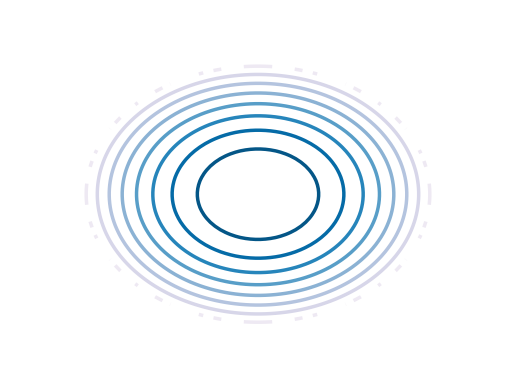

In [58]:
import numpy as np
import matplotlib.pyplot as plt
N = 100
x = np.linspace(-1, 1, N)
y = np.linspace(-1, 1, N)

xi, yi = np.meshgrid(x, y)
Z = xi**2 + yi**2
r1 = 0.7
mask_Z = xi**2 + yi**2 <= r1**2

zi = np.where(mask_Z, Z, np.nan)


fig, ax1 = plt.subplots()
ax1.contour(xi, yi, zi, levels=8, cmap="PuBu_r", linewidths=2.5)
ax1.axis("off")

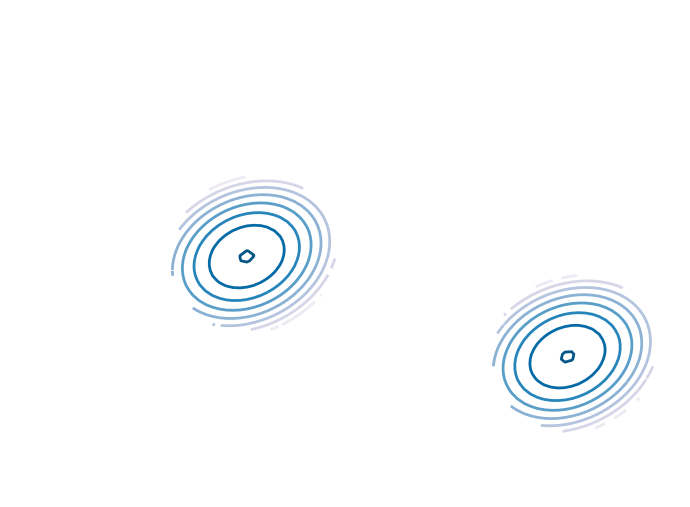

In [97]:
import numpy as np
import matplotlib.pyplot as plt

N = 100
x = np.linspace(-4, 7, N)  # extended range to fit second well
y = np.linspace(-4, 4, N)
xi, yi = np.meshgrid(x, y)

# ---- parameters ----
theta = np.deg2rad(25)   # rotation angle
ax_scale = 1.0           # ellipticity along rotated x'
ay_scale = 0.75          # ellipticity along rotated y'
tilt = 0.25              # small linear term to break symmetry
rx, ry = 1.4, 1.3        # ellipse radii
shift_x2 = 4.5  
shift_y2 = 2.0
# horizontal shift for second well
# ---------------------

# ---- FIRST WELL (centered at origin) ----
Xr1 =  xi*np.cos(theta) + yi*np.sin(theta)
Yr1 = -xi*np.sin(theta) + yi*np.cos(theta)

Z1 = (Xr1/ax_scale)**2 + (Yr1/ay_scale)**2 + tilt*Xr1
mask_Z1 = (Xr1/rx)**2 + (Yr1/ry)**2 <= 1.0
z1i = np.where(mask_Z1, Z1, np.nan)

# ---- SECOND WELL (shifted to the right) ----
xi2 = xi - shift_x2  # shift x-coordinates BEFORE rotation
yi2 = yi + shif_y2

Xr2 =  xi2*np.cos(theta) + yi*np.sin(theta)
Yr2 = -xi2*np.sin(theta) + yi2*np.cos(theta)

Z2 = (Xr2/ax_scale)**2 + (Yr2/ay_scale)**2 + tilt*Xr2
mask_Z2 = (Xr2/rx)**2 + (Yr2/ry)**2 <= 1.0
z2i = np.where(mask_Z2, Z2, np.nan)

# ---- PLOT ----
fig, ax1 = plt.subplots(figsize=(7, 8))

# First well
ax1.contour(xi, yi, z1i, levels=8, cmap="PuBu_r", linewidths=2)
ax1.contour(xi, yi, z2i, levels=8, cmap="PuBu_r", linewidths=2)
ax1.set_aspect("equal", adjustable="box")
ax1.axis("off")

plt.tight_layout()
plt.show()


/tmp/ipykernel_2393047/3586227661.py:46: RuntimeWarning: All-NaN slice encountered
  Z = np.nanmin(np.array([Z1, Z2, Z3]), axis=0)


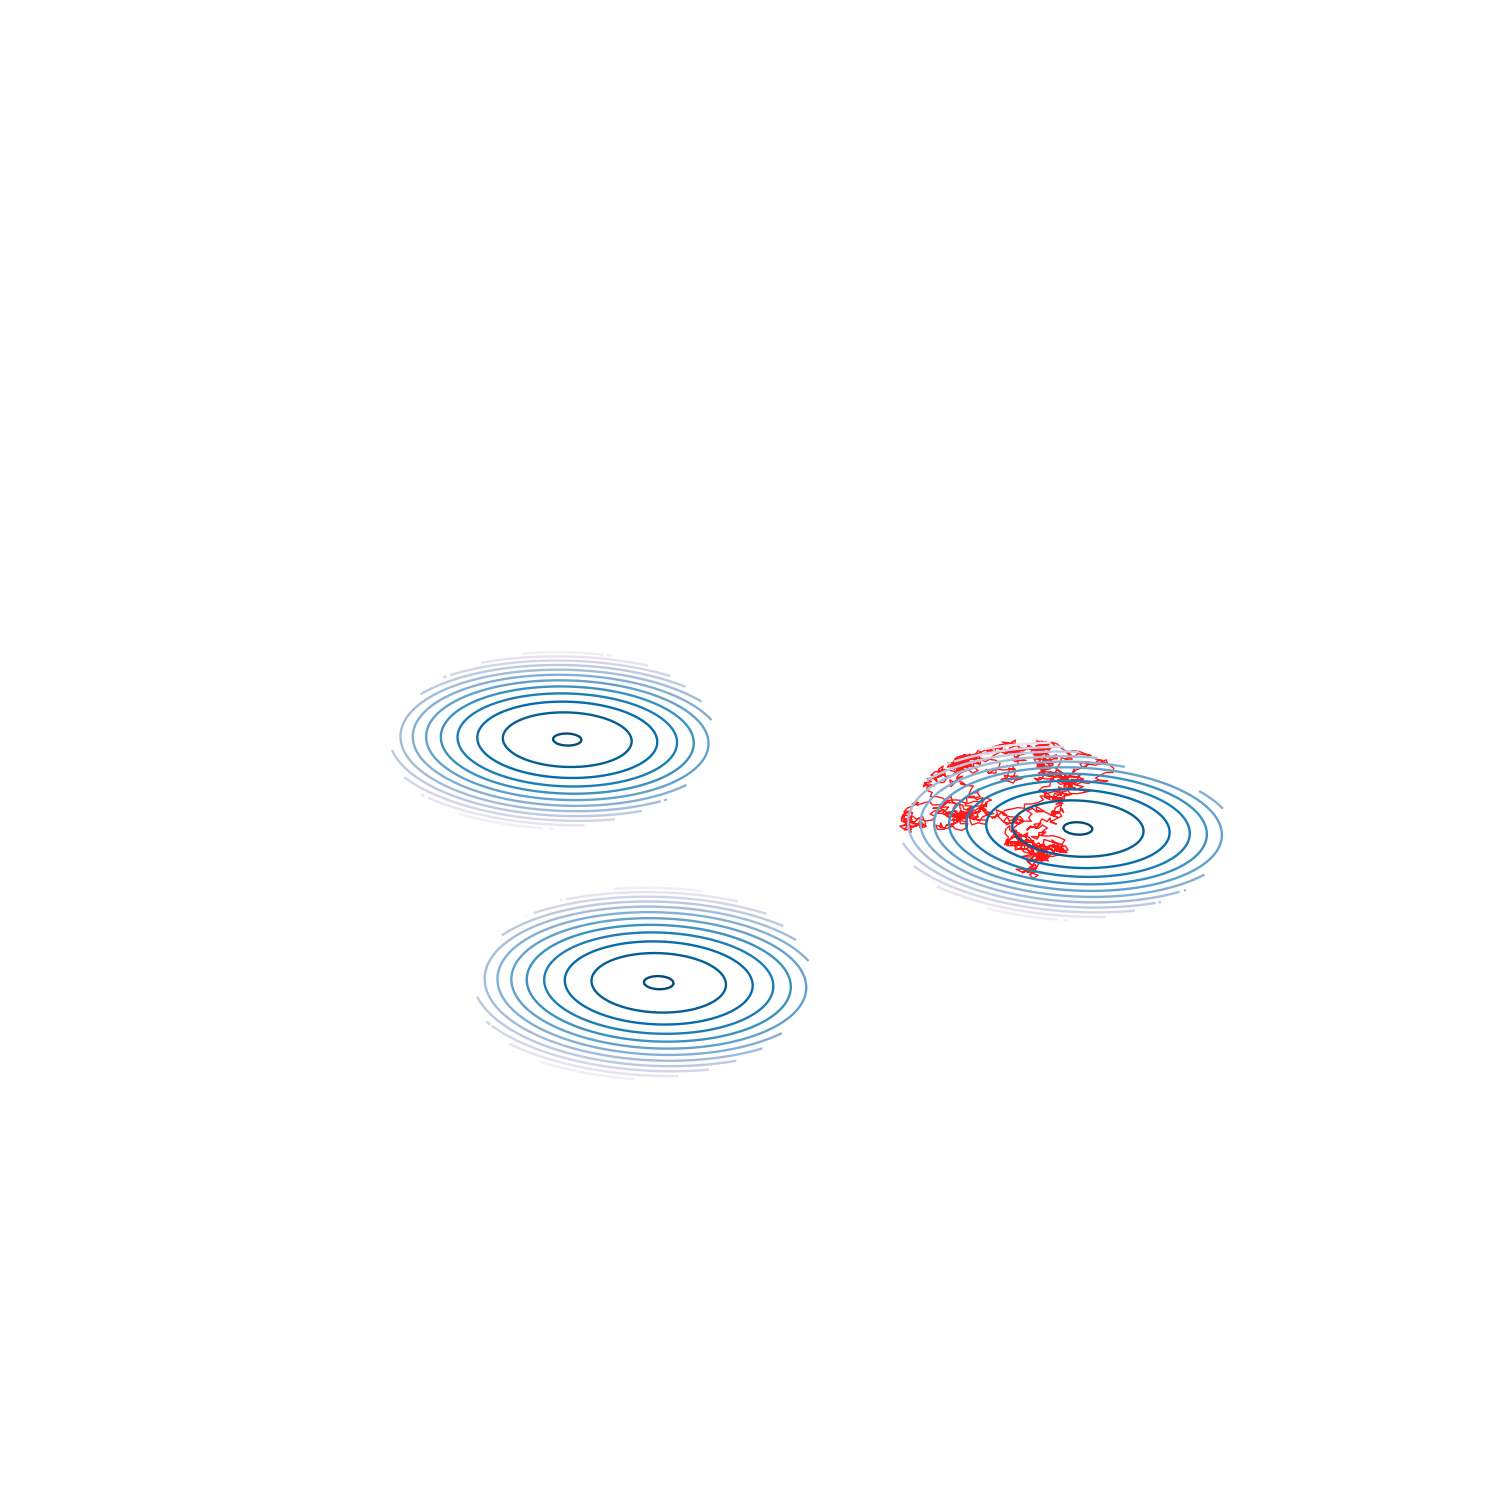

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Grid
N = 250
x = np.linspace(-2.5, 6, N)
y = np.linspace(-1, 5, N)
xi, yi = np.meshgrid(x, y)

# ---- parameters ----
theta = np.deg2rad(20)   # rotation angle for all wells
ax_scale = 1.0           # ellipticity along rotated x'
ay_scale = 0.7           # ellipticity along rotated y'
tilt = 0.25              # asymmetry term
rx, ry = 1.4, 1.3        # ellipse radii

# Well positions -> forms a non-equilateral triangle
center1 = (0.0, 0.0)     # bottom-left well
center2 = (4.5, 1.0)     # bottom-right well
center3 = (2.0, 3.5)     # top well
# ---------------------

def potential_well(xi, yi, x0, y0, theta):
    """Generate an elliptical rotated potential well centered at (x0, y0)."""
    Xs = xi - x0
    Ys = yi - y0

    # Rotate coordinates
    Xr =  Xs*np.cos(theta) + Ys*np.sin(theta)
    Yr = -Xs*np.sin(theta) + Ys*np.cos(theta)

    # Elliptical potential + asymmetry
    Z = (Xr/ax_scale)**2 + (Yr/ay_scale)**2 + tilt*Xr

    # Mask outside elliptical boundary
    mask = (Xr/rx)**2 + (Yr/ry)**2 <= 1.0
    return np.where(mask, Z, np.nan)

# Compute three separate wells
Z1 = potential_well(xi, yi, *center1, theta)
Z2 = potential_well(xi, yi, *center2, theta)
Z3 = potential_well(xi, yi, *center3, theta)

# Combine wells: take minimum potential wherever they overlap
Z = np.nanmin(np.array([Z1, Z2, Z3]), axis=0)

# ---- PLOT 3D CONTOUR PROJECTION ----
fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(111, projection="3d")

# Contour projections on XY-plane
ax.contour(
    xi, yi, Z,
    levels=12,
    cmap="PuBu_r",
    linewidths=1.7,
    offset=np.nanmin(Z) - 0.5
)

# Labels & view
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Potential")

# Better aspect ratio
ax.set_box_aspect([1.6, 1.2, 0.6])

# Set camera angle
ax.view_init(elev=35, azim=120)

# Cleaner look
ax.axis("off")

# --- Random trajectories inside the contour regions ---

# The same Z offset you used for contour projection
z_offset = np.nanmin(Z) - 0.5

# Precompute some helpers
valid = np.isfinite(Z)                # True where you're "inside"
dy = y[1] - y[0]
dx = x[1] - x[0]
Ny, Nx = valid.shape

def inside(xp, yp):
    """Return True if (xp, yp) lies on a valid (non-NaN) cell of Z."""
    j = int(round((xp - x[0]) / dx))  # column index in xi (x axis)
    i = int(round((yp - y[0]) / dy))  # row index in yi (y axis)
    if 0 <= i < Ny and 0 <= j < Nx:
        return valid[i, j]
    return False

def random_start():
    """Pick a random valid starting point from the grid."""
    # Sample indices from the mask
    ii, jj = np.where(valid)
    k = np.random.randint(0, len(ii))
    return x[jj[k]], y[ii[k]]

def random_walk(n_steps=800, step=0.5, max_tries=20):
    """Generate a single bounded random walk that stays inside the mask."""
    xp, yp = random_start()
    xs = [xp]; ys = [yp]
    for _ in range(n_steps):
        # Try a few random directions until one stays inside
        accepted = False
        for _ in range(max_tries):
            ang = np.random.uniform(0, 2*np.pi)
            xn = xp + step*np.cos(ang)
            yn = yp + step*np.sin(ang)
            if inside(xn, yn):
                xp, yp = xn, yn
                xs.append(xp); ys.append(yp)
                accepted = True
                break
        if not accepted:
            # If stuck, restart somewhere else inside
            xp, yp = random_start()
            xs.append(xp); ys.append(yp)
    return np.array(xs), np.array(ys)

# Generate and plot a few trajectories
num_paths = 1
for _ in range(num_paths):
    xs, ys = random_walk(n_steps=1200, step=0.06)
    ax.plot(xs, ys, zs=z_offset, c="r", zdir='z', lw=1, alpha=0.9)

# (Everything else the same; your contour + axis settings remain)


plt.tight_layout()
plt.show()
